In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("CO2 Emissions_Canada.csv")
data.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [3]:
data[
    (data["Make"] == "HONDA") &
    (data["Model"] == "ACCORD") &
    (data["Vehicle Class"] == "MID-SIZE")
]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
481,HONDA,ACCORD,MID-SIZE,2.4,4,AV,X,9.0,6.6,7.9,36,182
482,HONDA,ACCORD,MID-SIZE,2.4,4,AV7,X,9.1,6.9,8.1,35,186
483,HONDA,ACCORD,MID-SIZE,2.4,4,M6,X,10.1,6.9,8.7,32,200
484,HONDA,ACCORD,MID-SIZE,3.5,6,A6,X,11.0,6.8,9.1,31,209
485,HONDA,ACCORD,MID-SIZE,3.5,6,AS6,X,11.4,7.3,9.6,29,221
486,HONDA,ACCORD,MID-SIZE,3.5,6,M6,X,13.0,8.4,10.9,26,251
1563,HONDA,ACCORD,MID-SIZE,2.4,4,AV,X,8.8,6.5,7.8,36,179
1564,HONDA,ACCORD,MID-SIZE,2.4,4,AV7,X,9.0,6.7,8.0,35,184
1565,HONDA,ACCORD,MID-SIZE,2.4,4,M6,X,10.1,6.9,8.7,32,200
1566,HONDA,ACCORD,MID-SIZE,3.5,6,A6,X,11.0,6.8,9.1,31,209


In [4]:
cylinder_4 = data[
    (data["Make"] == "HONDA") &
    (data["Model"] == "ACCORD") &
    (data["Vehicle Class"] == "MID-SIZE") &
    (data["Cylinders"] == 4)
]
cylinder_6 = data[
    (data["Make"] == "HONDA") &
    (data["Model"] == "ACCORD") &
    (data["Vehicle Class"] == "MID-SIZE") &
    (data["Cylinders"] == 6)
]

co2_em_cylinder_4 = cylinder_4["CO2 Emissions(g/km)"]
co2_em_cylinder_6 = cylinder_6["CO2 Emissions(g/km)"]

co2_em_cylinder_4, co2_em_cylinder_6

(481     182
 482     186
 483     200
 1563    179
 1564    184
 1565    200
 2697    207
 3783    190
 3784    210
 Name: CO2 Emissions(g/km), dtype: int64,
 484     209
 485     221
 486     251
 1566    209
 1567    219
 1568    251
 Name: CO2 Emissions(g/km), dtype: int64)

In [5]:
result = pd.concat(
    [
        co2_em_cylinder_4.reset_index(drop=True),
        co2_em_cylinder_6.reset_index(drop=True)
    ],
    axis=1
)

result.columns = ["4 Cylinders", "6 Cylinders"]
result

,4 Cylinders,6 Cylinders
0,182,209.0
1,186,221.0
2,200,251.0
3,179,209.0
4,184,219.0
5,200,251.0
6,207,NaN
7,190,NaN
8,210,NaN


In [6]:
result["6 Cylinders"] = result["6 Cylinders"].fillna(int(result["6 Cylinders"].mean()))
result

,4 Cylinders,6 Cylinders
0,182,209.0
1,186,221.0
2,200,251.0
3,179,209.0
4,184,219.0
5,200,251.0
6,207,226.0
7,190,226.0
8,210,226.0


## Two-Sided Hypothesis Test (Bilateral)

**Null Hypothesis (H₀):**  
$$
H_0 : \tilde{D} = 0
$$

(The median difference in CO₂ emissions between 4-cylinder and 6-cylinder vehicles is zero.)

**Alternative Hypothesis (H₁):**  
$$
H_1 : \tilde{D} \neq 0
$$

(The median difference in CO₂ emissions between 4-cylinder and 6-cylinder vehicles is not zero.)

In [7]:
from scipy.stats import wilcoxon

# Wilcoxon Signed-Rank Test (paired, two-sided)
stat, p_value = wilcoxon(
    result["6 Cylinders"],
    result["4 Cylinders"],
    alternative="two-sided"
)

print("Wilcoxon Signed-Rank Test results:")
print(f"Test statistic (W) = {stat}")
print(f"p-value            = {p_value:.6f}")

Wilcoxon Signed-Rank Test results:
Test statistic (W) = 0.0
p-value            = 0.003906


### Wilcoxon Signed-Rank Test Results

A Wilcoxon Signed-Rank Test was conducted to compare the CO₂ emissions of 4-cylinder and 6-cylinder vehicles using paired observations.

The test results were as follows:

- Test statistic (W) = 0.0  
- p-value = 0.003906  

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.  
This indicates a statistically significant difference between the CO₂ emissions of 4-cylinder and 6-cylinder vehicles.

The result suggests that the number of cylinders has a significant effect on CO₂ emissions.

In [43]:
from scipy.stats import shapiro

stat_4, p_4 = shapiro(result["4 Cylinders"])
print(f"4 Cylinders: W={stat_4:.3f}, p-value={p_4:.4f}")

stat_6, p_6 = shapiro(result["6 Cylinders"])
print(f"6 Cylinders: W={stat_6:.3f}, p-value={p_6:.4f}")

4 Cylinders: W=0.917, p-value=0.3645
6 Cylinders: W=0.851, p-value=0.0759


In [44]:
diff = result["6 Cylinders"] - result["4 Cylinders"]

stat_diff, p_diff = shapiro(diff)

print(f"Difference: W={stat_diff:.3f}, p-value={p_diff:.4f}")

Difference: W=0.925, p-value=0.4383


In [45]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    result["6 Cylinders"],
    result["4 Cylinders"]
)

print(f"Paired t-test results:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.4f}")

Paired t-test results:
t-statistic = 8.185
p-value     = 0.0000


In [46]:
# Cohen's d (paired)
cohens_d = diff.mean() / diff.std(ddof=1)

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 2.728


In [47]:
from scipy.stats import wilcoxon

# Wilcoxon Signed-Rank Test (paired, two-sided)
stat, p_value = wilcoxon(
    result["6 Cylinders"],
    result["4 Cylinders"],
    alternative="two-sided"
)

print("Wilcoxon Signed-Rank Test results:")
print(f"Test statistic (W) = {stat}")
print(f"p-value            = {p_value:.6f}")

Wilcoxon Signed-Rank Test results:
Test statistic (W) = 0.0
p-value            = 0.003906


In [49]:
# One-sided Wilcoxon Signed-Rank Test
stat, p_value = wilcoxon(
    result["6 Cylinders"],
    result["4 Cylinders"],
    alternative="greater"  # H1: group6 > group4
)

print("One-sided Wilcoxon Signed-Rank Test results:")
print(f"Test statistic (W) = {stat}")
print(f"p-value            = {p_value:.6f}")

One-sided Wilcoxon Signed-Rank Test results:
Test statistic (W) = 45.0
p-value            = 0.001953


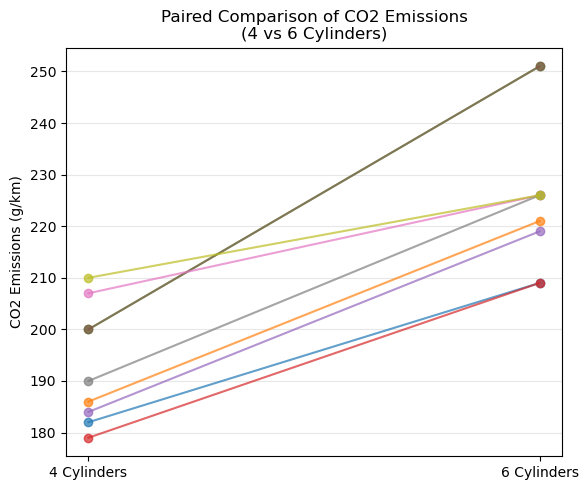

In [51]:
# X positions
x = [0, 1]

# Plot paired lines
plt.figure(figsize=(6, 5))
for i in range(len(result)):
    plt.plot(
        x,
        [result.loc[i, "4 Cylinders"], result.loc[i, "6 Cylinders"]],
        marker="o",
        alpha=0.7
    )

# Axis formatting
plt.xticks([0, 1], ["4 Cylinders", "6 Cylinders"])
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Paired Comparison of CO2 Emissions\n(4 vs 6 Cylinders)")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

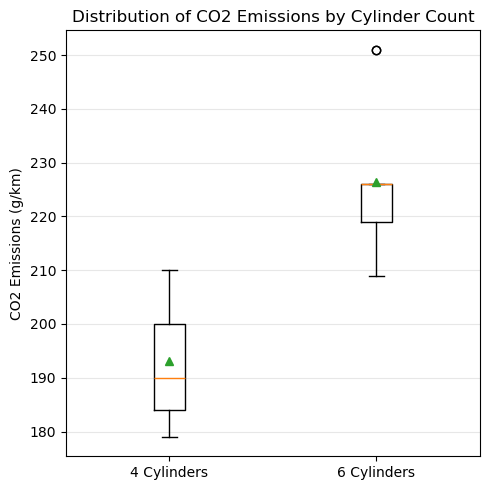

In [52]:
plt.figure(figsize=(5, 5))

plt.boxplot(
    [result["4 Cylinders"], result["6 Cylinders"]],
    labels=["4 Cylinders", "6 Cylinders"],
    showmeans=True
)

plt.ylabel("CO2 Emissions (g/km)")
plt.title("Distribution of CO2 Emissions by Cylinder Count")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## One-Sided Hypothesis Test (Directional)

Let

$$
D = CO_{2}^{(6)} - CO_{2}^{(4)}
$$

**Null Hypothesis (H₀):**

$$
H_0 : \tilde{D} \leq 0
$$

(The median CO₂ emission of 6-cylinder vehicles is less than or equal to that of 4-cylinder vehicles.)

**Alternative Hypothesis (H₁):**

$$
H_1 : \tilde{D} > 0
$$

(The median CO₂ emission of 6-cylinder vehicles is greater than that of 4-cylinder vehicles.)

In [8]:
# One-sided Wilcoxon Signed-Rank Test
stat, p_value = wilcoxon(
    result["6 Cylinders"],
    result["4 Cylinders"],
    alternative="greater"  # H1: group6 > group4
)

print("One-sided Wilcoxon Signed-Rank Test results:")
print(f"Test statistic (W) = {stat}")
print(f"p-value            = {p_value:.6f}")

One-sided Wilcoxon Signed-Rank Test results:
Test statistic (W) = 45.0
p-value            = 0.001953


### One-Sided Wilcoxon Signed-Rank Test Results

A one-sided Wilcoxon Signed-Rank Test was performed to evaluate whether 6-cylinder vehicles emit more CO₂ than 4-cylinder vehicles using paired observations.

The test produced the following results:

- Test statistic (W) = 45.0  
- p-value = 0.001953  

Since the p-value is smaller than the significance level of 0.05, the null hypothesis is rejected.  
This provides strong statistical evidence that 6-cylinder vehicles have higher CO₂ emissions than 4-cylinder vehicles.

Therefore, it can be concluded that an increase in the number of cylinders is associated with an increase in CO₂ emissions.


## Graphs

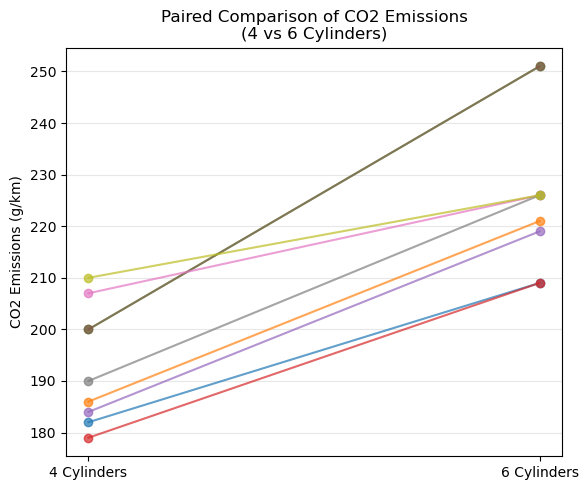

In [9]:
# X positions
x = [0, 1]

# Plot paired lines
plt.figure(figsize=(6, 5))
for i in range(len(result)):
    plt.plot(
        x,
        [result.loc[i, "4 Cylinders"], result.loc[i, "6 Cylinders"]],
        marker="o",
        alpha=0.7
    )

# Axis formatting
plt.xticks([0, 1], ["4 Cylinders", "6 Cylinders"])
plt.ylabel("CO2 Emissions (g/km)")
plt.title("Paired Comparison of CO2 Emissions\n(4 vs 6 Cylinders)")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization Interpretation

The paired line plot illustrates the within-model comparison of CO₂ emissions between 4-cylinder and 6-cylinder vehicles.  
Each line represents the same vehicle model, with CO₂ emissions measured under two different cylinder configurations.

As observed in the figure, all paired lines show an upward trend from 4-cylinder to 6-cylinder vehicles, indicating higher CO₂ emissions for 6-cylinder engines across all matched observations. No pair exhibits a decrease or equal emission level when moving from 4 to 6 cylinders.

This consistent directional increase explains the Wilcoxon Signed-Rank Test results, where all differences were positive, leading to a highly significant p-value in both the two-sided (p = 0.003906) and one-sided (p = 0.001953) tests.

Overall, the visualization provides strong visual evidence that increasing the number of cylinders is associated with increased CO₂ emissions, supporting the alternative hypothesis of the one-sided Wilcoxon Signed-Rank Test.

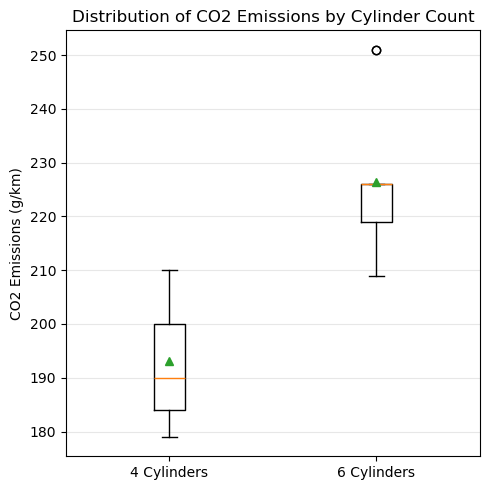

In [10]:
plt.figure(figsize=(5, 5))

plt.boxplot(
    [result["4 Cylinders"], result["6 Cylinders"]],
    labels=["4 Cylinders", "6 Cylinders"],
    showmeans=True
)

plt.ylabel("CO2 Emissions (g/km)")
plt.title("Distribution of CO2 Emissions by Cylinder Count")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Boxplot Interpretation

The boxplot compares the distributions of CO₂ emissions for 4-cylinder and 6-cylinder vehicles.

The median CO₂ emission of 6-cylinder vehicles is clearly higher than that of 4-cylinder vehicles.  
Additionally, the entire interquartile range (IQR) of the 6-cylinder group is shifted upward relative to the 4-cylinder group, indicating consistently higher emission levels rather than being driven by a small number of extreme values.

The mean value (shown by the marker) is also higher for the 6-cylinder vehicles, further supporting the observed difference between the two groups.

These distributional differences are consistent with the results of the Wilcoxon Signed-Rank Test, which indicated a statistically significant increase in CO₂ emissions for 6-cylinder vehicles compared to 4-cylinder vehicles (one-sided p = 0.001953).

Overall, the boxplot provides strong visual evidence that vehicles with a higher number of cylinders tend to produce higher CO₂ emissions.